## What are the most demanded skills for the top 3 most popular data roles?

#### Methodology
1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. Calculate skill percentage
4. Plot final findings

In [2]:
# Import Library 
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns

# load data 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_INA = df[df['job_country'] == 'Indonesia'].copy()
df_INA.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
643,Data Scientist,Data Scientist,"Bali, Indonesia",via HR Software For Growing Businesses | Fresh...,Full-time,False,Indonesia,2023-07-03 13:14:47,False,False,Indonesia,None,NaN,NaN,Tyrads PTE. LTD.,"[python, r, aws, gcp, azure, spark, hadoop, ta...","{'analyst_tools': ['tableau', 'power bi'], 'cl..."
1213,Data Scientist,Data Scientist,Indonesia,via Linkedin,Full-time,False,Indonesia,2023-04-17 13:19:59,False,False,Indonesia,None,NaN,NaN,Robert Walters,"[python, sql]","{'programming': ['python', 'sql']}"
1244,Data Engineer,Data Engineer,"Jakarta, Indonesia",via LinkedIn,Full-time,False,Indonesia,2023-08-31 13:44:04,True,False,Indonesia,None,NaN,NaN,JULO,"[sql, java, python, postgresql, redshift, aws,...","{'cloud': ['redshift', 'aws', 'gcp', 'azure'],..."
1858,Data Engineer,Data Engineer - ETL Developer,"Jakarta, Indonesia",via LinkedIn,Contractor,False,Indonesia,2023-05-29 13:14:42,False,False,Indonesia,None,NaN,NaN,PT. IDStar Cipta Teknologi (IDstar),"[sql, oracle, spark, kafka]","{'cloud': ['oracle'], 'libraries': ['spark', '..."
2048,Senior Data Scientist,Senior Data Scientist,Indonesia,via LinkedIn,Full-time,False,Indonesia,2023-05-25 13:32:17,False,False,Indonesia,None,NaN,NaN,Robert Walters,"[sql, python]","{'programming': ['sql', 'python']}"


In [4]:
df_skills = df_INA.explode('job_skills')

In [5]:
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count = df_skills_count.sort_values(by='skill_count', ascending=False)

df_skills_count

,job_skills,job_title_short,skill_count
718,sql,Data Engineer,596
555,python,Data Engineer,455
556,python,Data Scientist,342
719,sql,Data Scientist,319
689,spark,Data Engineer,235
...,...,...,...
657,sharepoint,Senior Data Analyst,1
315,jenkins,Machine Learning Engineer,1
659,sheets,Business Analyst,1
660,sheets,Cloud Engineer,1


In [6]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

<function matplotlib.pyplot.show(close=None, block=None)>

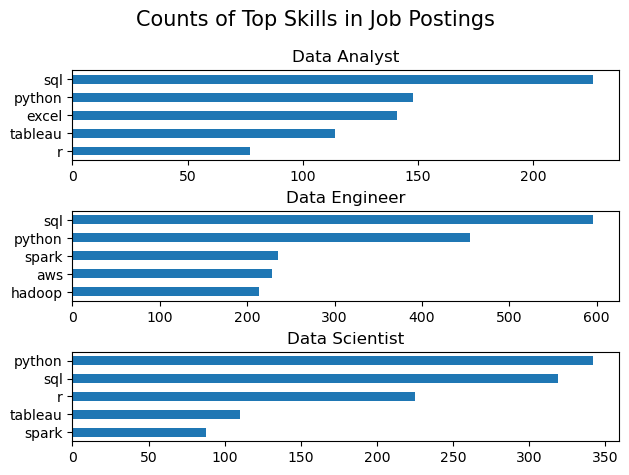

In [7]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show


In [8]:
df_job_title_count = df_INA['job_title_short'].value_counts().reset_index(name='job_total')

In [9]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count'] / df_skills_perc['job_total']

df_skills_perc

,job_skills,job_title_short,skill_count,job_total,skill_percent
0,sql,Data Engineer,596,1040,57.307692
1,python,Data Engineer,455,1040,43.750000
2,python,Data Scientist,342,645,53.023256
3,sql,Data Scientist,319,645,49.457364
4,spark,Data Engineer,235,1040,22.596154
...,...,...,...,...,...
840,sharepoint,Senior Data Analyst,1,50,2.000000
841,jenkins,Machine Learning Engineer,1,67,1.492537
842,sheets,Business Analyst,1,115,0.869565
843,sheets,Cloud Engineer,1,101,0.990099


<function matplotlib.pyplot.show(close=None, block=None)>

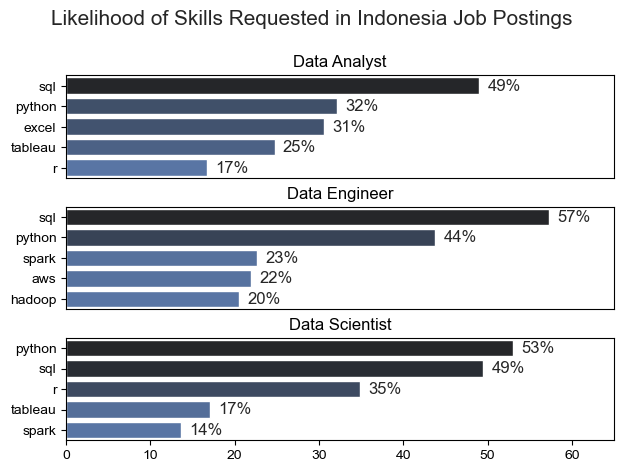

In [10]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0,65)

    for number, value in enumerate(df_plot['skill_percent']):
        ax[i].text(value + 1, number, f'{value:.0f}%', va='center')

    if i != len(job_titles) -1:
        ax[i].set_xticks([])

fig.suptitle('Likelihood of Skills Requested in Indonesia Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show
